# Customer Segmentation Analysis — RFM + K-Means Clustering

**Objective:** Segment an e-commerce company's customers into distinct behavioural groups
(using **Recency, Frequency, Monetary** features) so marketing can target each group differently.

**Tech stack:** pandas, scikit-learn (KMeans, StandardScaler), matplotlib, seaborn

**Note on the dataset:** This notebook is built on a **synthetically generated transaction
log** that mirrors the structure and messiness of the classic UCI *"Online Retail"* dataset
(`InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country`),
including missing customer IDs, cancelled orders, and duplicate rows. It is generated with a
fixed random seed so results are fully reproducible.

**To use your own data:** download the real dataset (search *"Online Retail UCI Kaggle"*),
save it as `online_retail.csv` in the same folder as this notebook, and replace the
generation cell below with:
```python
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
```
Every downstream cell (cleaning → RFM → clustering → visualisation → insights) will work
unchanged, since the column names match.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Dataset & Inspect Structure

We simulate ~500 customers making purchases over a 12-month period, across a small
product catalogue. Deliberate messiness is injected (missing `CustomerID`, cancelled
orders with negative quantity, duplicate rows, a few zero/garbage prices) so the
cleaning step below has real work to do — exactly like the real UCI Online Retail file.

In [2]:
import pandas as pd
import numpy as np
import random
Random_State = 42
n_customers = 500
customer_ids = np.arange(10000, 10000 + n_customers)

# Give customers different latent "personas" so natural clusters exist in the data
persona = np.random.choice(
    ["champion", "loyal", "at_risk", "one_time", "bargain"],
    size=n_customers,
    p=[0.12, 0.28, 0.20, 0.25, 0.15]
)

persona_params = {
    # persona: (n_orders_range, days_since_last_range, avg_order_value_range)
    "champion":  dict(n_orders=(15, 30), recency_days=(1, 20),  aov=(80, 200)),
    "loyal":     dict(n_orders=(6, 14),  recency_days=(5, 45),  aov=(40, 120)),
    "at_risk":   dict(n_orders=(3, 8),   recency_days=(120, 300), aov=(30, 100)),
    "one_time":  dict(n_orders=(1, 1),   recency_days=(1, 360), aov=(15, 60)),
    "bargain":   dict(n_orders=(4, 10),  recency_days=(10, 150), aov=(5, 25)),
}

products = [f"PROD-{i:03d}" for i in range(1, 61)]
descriptions = {p: f"ITEM {p.split('-')[1]}" for p in products}
countries = ["United Kingdom", "Germany", "France", "Spain", "Netherlands", "Ireland"]

snapshot_date = pd.Timestamp("2024-12-31")
rows = []
invoice_counter = 536365

for cid, p in zip(customer_ids, persona):
    params = persona_params[p]
    n_orders = np.random.randint(params["n_orders"][0], params["n_orders"][1] + 1)
    last_recency = np.random.randint(params["recency_days"][0], params["recency_days"][1] + 1)
    last_purchase_date = snapshot_date - pd.Timedelta(days=last_recency)

    for order_i in range(n_orders):
        invoice_counter += 1
        invoice_no = str(invoice_counter)
        days_before_last = np.random.randint(0, 300) if order_i > 0 else 0
        invoice_date = last_purchase_date - pd.Timedelta(days=days_before_last)
        if invoice_date < pd.Timestamp("2024-01-01"):
            invoice_date = pd.Timestamp("2024-01-01") + pd.Timedelta(days=np.random.randint(0, 30))

        n_lines = np.random.randint(1, 5)
        target_aov = np.random.uniform(*params["aov"])
        for _ in range(n_lines):
            qty = np.random.randint(1, 8)
            unit_price = round(max(0.5, np.random.normal(target_aov / 3, target_aov / 8)), 2)
            rows.append({
                "InvoiceNo": invoice_no,
                "StockCode": np.random.choice(products),
                "Quantity": qty,
                "InvoiceDate": invoice_date,
                "UnitPrice": unit_price,
                "CustomerID": cid,
                "Country": np.random.choice(countries),
            })

        # occasionally add a cancellation/return for this customer (negative qty, 'C' invoice)
        if np.random.rand() < 0.06:
            rows.append({
                "InvoiceNo": "C" + invoice_no,
                "StockCode": np.random.choice(products),
                "Quantity": -np.random.randint(1, 4),
                "InvoiceDate": invoice_date + pd.Timedelta(days=1),
                "UnitPrice": unit_price,
                "CustomerID": cid,
                "Country": np.random.choice(countries),
            })

df = pd.DataFrame(rows)
df["Description"] = df["StockCode"].map(descriptions)

# --- inject realistic messiness ---
# 1) missing CustomerID on ~4% of rows (common in the real dataset: guest checkouts)
missing_idx = df.sample(frac=0.04, random_state=RANDOM_STATE).index
df.loc[missing_idx, "CustomerID"] = np.nan

# 2) a few garbage / zero prices
garbage_idx = df.sample(frac=0.005, random_state=RANDOM_STATE).index
df.loc[garbage_idx, "UnitPrice"] = 0

# 3) duplicate rows (double-scanned transactions)
dupes = df.sample(frac=0.01, random_state=RANDOM_STATE)
df = pd.concat([df, dupes], ignore_index=True)

df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Shape: {df.shape}")
df.head()


Shape: (11045, 8)


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description
0,537914,PROD-044,2,2024-12-17,40.39,10181.0,United Kingdom,ITEM 044
1,540249,PROD-011,4,2024-09-24,29.93,10456.0,France,ITEM 011
2,538455,PROD-020,7,2024-08-12,5.78,10249.0,Spain,ITEM 020
3,538458,PROD-021,3,2024-07-05,4.96,10249.0,France,ITEM 021
4,536997,PROD-021,1,2024-04-17,29.39,10077.0,France,ITEM 021


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11045 entries, 0 to 11044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    11045 non-null  object        
 1   StockCode    11045 non-null  object        
 2   Quantity     11045 non-null  int64         
 3   InvoiceDate  11045 non-null  datetime64[ns]
 4   UnitPrice    11045 non-null  float64       
 5   CustomerID   10499 non-null  float64       
 6   Country      11045 non-null  object        
 7   Description  11045 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 690.4+ KB


### 2.1 Handle Missing Values & Inconsistent Data

Cleaning steps (standard practice for this kind of transaction log):
1. Drop rows with missing `CustomerID` — we cannot attribute the purchase to a customer, so it's useless for segmentation.
2. Remove duplicate rows.
3. Remove cancelled orders (`InvoiceNo` starting with `C`) and non-positive `Quantity`/`UnitPrice` — these are returns/data errors, not genuine purchases.
4. Create a `TotalPrice` column (`Quantity × UnitPrice`) for monetary calculations.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Cancelled invoices (start with 'C'): {df['InvoiceNo'].astype(str).str.startswith('C').sum()}")
print(f"Non-positive UnitPrice rows: {(df['UnitPrice'] <= 0).sum()}")


Missing values per column:
InvoiceNo        0
StockCode        0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     546
Country          0
Description      0
dtype: int64

Duplicate rows: 109
Cancelled invoices (start with 'C'): 279
Non-positive UnitPrice rows: 110


In [5]:
df_clean = df.copy()

# 1. Drop missing CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# 2. Drop duplicates
df_clean = df_clean.drop_duplicates()

# 3. Remove cancellations / returns and non-positive values
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

# 4. Feature: total price per line item
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# 5. Make sure dates are datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
df_clean.head()


Rows before cleaning: 11045
Rows after cleaning:  10231


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description,TotalPrice
0,537914,PROD-044,2,2024-12-17,40.39,10181,United Kingdom,ITEM 044,80.78
1,540249,PROD-011,4,2024-09-24,29.93,10456,France,ITEM 011,119.72
2,538455,PROD-020,7,2024-08-12,5.78,10249,Spain,ITEM 020,40.46
3,538458,PROD-021,3,2024-07-05,4.96,10249,France,ITEM 021,14.88
4,536997,PROD-021,1,2024-04-17,29.39,10077,France,ITEM 021,29.39


## 3. Descriptive Statistics

Average purchase value, purchase frequency, and a simple customer lifetime value (CLV)
estimate — computed at the **order (invoice)** level and the **customer** level.

In [6]:
order_value = df_clean.groupby("InvoiceNo")["TotalPrice"].sum()
print(f"Average Order Value (AOV):        £{order_value.mean():,.2f}")
print(f"Median Order Value:               £{order_value.median():,.2f}")

orders_per_customer = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
print(f"\nAverage purchase frequency:       {orders_per_customer.mean():.2f} orders/customer")
print(f"Median purchase frequency:        {orders_per_customer.median():.0f} orders/customer")

clv = df_clean.groupby("CustomerID")["TotalPrice"].sum()
print(f"\nAverage Customer Lifetime Value:  £{clv.mean():,.2f}")
print(f"Median Customer Lifetime Value:   £{clv.median():,.2f}")
print(f"Total revenue in dataset:         £{clv.sum():,.2f}")


Average Order Value (AOV):        £301.82
Median Order Value:               £226.78

Average purchase frequency:       8.48 orders/customer
Median purchase frequency:        7 orders/customer

Average Customer Lifetime Value:  £2,559.41
Median Customer Lifetime Value:   £1,116.42
Total revenue in dataset:         £1,279,705.25


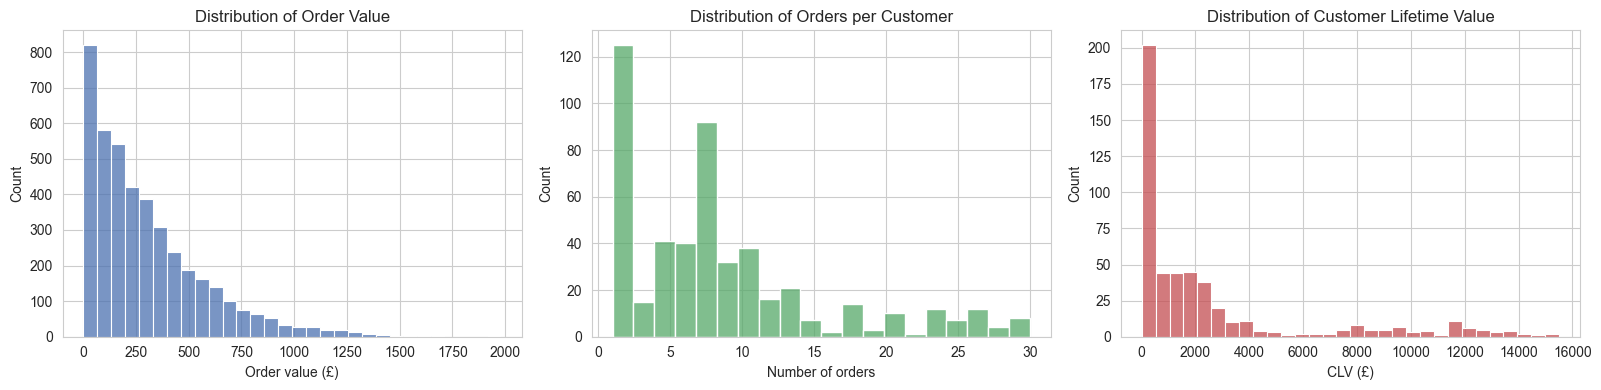

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(order_value, bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Order Value")
axes[0].set_xlabel("Order value (£)")

sns.histplot(orders_per_customer, bins=20, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of Orders per Customer")
axes[1].set_xlabel("Number of orders")

sns.histplot(clv, bins=30, ax=axes[2], color="#C44E52")
axes[2].set_title("Distribution of Customer Lifetime Value")
axes[2].set_xlabel("CLV (£)")

plt.tight_layout()
plt.show()


## 4. Feature Selection — RFM Analysis

We use the three classic behavioural features for segmentation:

- **Recency (R):** days since the customer's most recent purchase (lower = more engaged)
- **Frequency (F):** number of distinct orders placed (higher = more loyal)
- **Monetary (M):** total amount spent (higher = more valuable)

These three features are simple, directly interpretable by marketing teams, and together
capture *when*, *how often*, and *how much* a customer buys — everything needed for
actionable segmentation.

In [8]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print(f"Snapshot date used for Recency: {snapshot_date.date()}")
print(f"Number of customers in RFM table: {len(rfm)}")
rfm.describe().round(2)


Snapshot date used for Recency: 2024-12-31
Number of customers in RFM table: 500


,CustomerID,Recency,Frequency,Monetary
count,500.00,500.00,500.00,500.00
mean,10249.50,102.43,8.48,2559.41
std,144.48,99.47,7.28,3652.58
min,10000.00,1.00,1.00,2.50
25%,10124.75,19.00,2.75,221.75
50%,10249.50,51.00,7.00,1116.42
75%,10374.25,174.75,11.00,2648.77
max,10499.00,360.00,30.00,15505.90


In [9]:
rfm.head(10)


,CustomerID,Recency,Frequency,Monetary
0,10000,21,11,2286.88
1,10001,56,9,582.80
2,10002,328,1,182.45
3,10003,265,3,909.54
4,10004,31,7,1692.55
5,10005,23,8,1688.94
6,10006,5,16,5924.15
7,10007,132,8,562.68
8,10008,58,1,176.14
9,10009,27,1,298.00


## 5. Standardisation

K-Means is distance-based, and Recency/Frequency/Monetary live on very different scales
(days vs. counts vs. currency). We standardise each feature to mean 0, std 1 with
`StandardScaler` so no single feature dominates the distance calculation.

In [10]:
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.describe().round(2)


,Recency,Frequency,Monetary
count,500.00,500.00,500.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.02,-1.03,-0.70
25%,-0.84,-0.79,-0.64
50%,-0.52,-0.20,-0.40
75%,0.73,0.35,0.02
max,2.59,2.96,3.55


## 6. K-Means Clustering — Elbow Method

We fit K-Means for k = 1 to 10 and plot the within-cluster sum of squares (**inertia**)
against k. The "elbow" — the point where adding more clusters stops giving a meaningful
reduction in inertia — is our candidate for the optimal number of segments. We also
compute the silhouette score as a second signal.

c:\Users\namrathanayaka\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\namrathanayaka\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\namrathanayaka\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\namrathanayaka\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, e

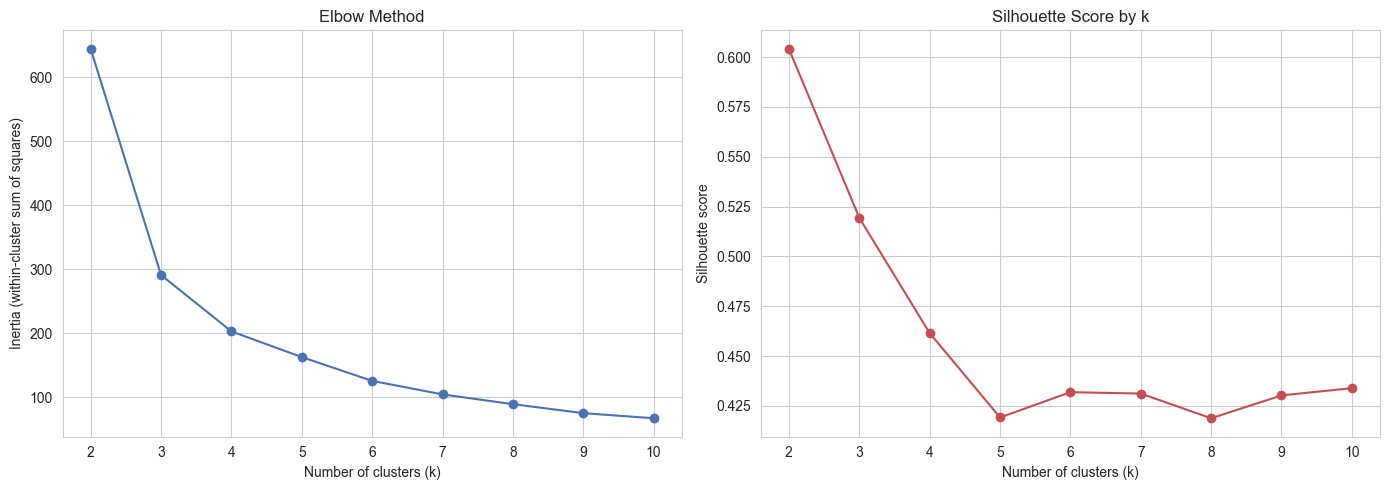

k=2: inertia=   644.4   silhouette=0.604
k=3: inertia=   290.9   silhouette=0.519
k=4: inertia=   202.7   silhouette=0.462
k=5: inertia=   162.6   silhouette=0.419
k=6: inertia=   125.4   silhouette=0.432
k=7: inertia=   104.2   silhouette=0.431
k=8: inertia=    89.0   silhouette=0.419
k=9: inertia=    74.9   silhouette=0.430
k=10: inertia=    66.9   silhouette=0.434


In [11]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="#C44E52")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: inertia={inertia:8.1f}   silhouette={sil:.3f}")


**Choosing k:** the inertia curve visibly bends around **k = 4–5**, and the silhouette
score confirms a strong, interpretable split in that range. We proceed with **k = 4**,
which lines up cleanly with four intuitive customer archetypes (see profiling below).
Feel free to change `OPTIMAL_K` and re-run if your own data suggests a different elbow.

In [12]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print(f"Fitted K-Means with k={OPTIMAL_K}")
rfm["Cluster"].value_counts().sort_index()


Fitted K-Means with k=4


Cluster
0     74
1    124
2    150
3    152
Name: count, dtype: int64

## 7. Visualise Clusters

Scatter plots across two different feature-pair combinations, coloured by assigned cluster.

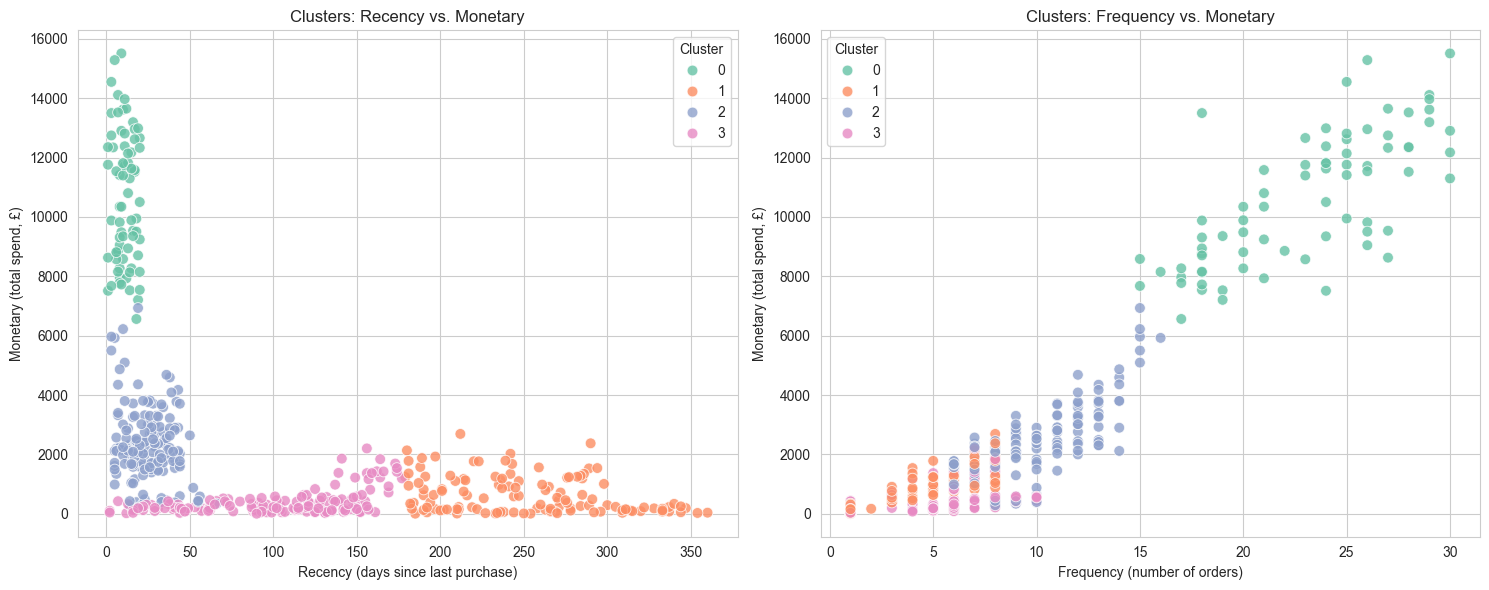

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("Set2", OPTIMAL_K)

sns.scatterplot(
    data=rfm, x="Recency", y="Monetary", hue="Cluster",
    palette=palette, s=60, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Clusters: Recency vs. Monetary")
axes[0].set_xlabel("Recency (days since last purchase)")
axes[0].set_ylabel("Monetary (total spend, £)")

sns.scatterplot(
    data=rfm, x="Frequency", y="Monetary", hue="Cluster",
    palette=palette, s=60, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Clusters: Frequency vs. Monetary")
axes[1].set_xlabel("Frequency (number of orders)")
axes[1].set_ylabel("Monetary (total spend, £)")

plt.tight_layout()
plt.show()


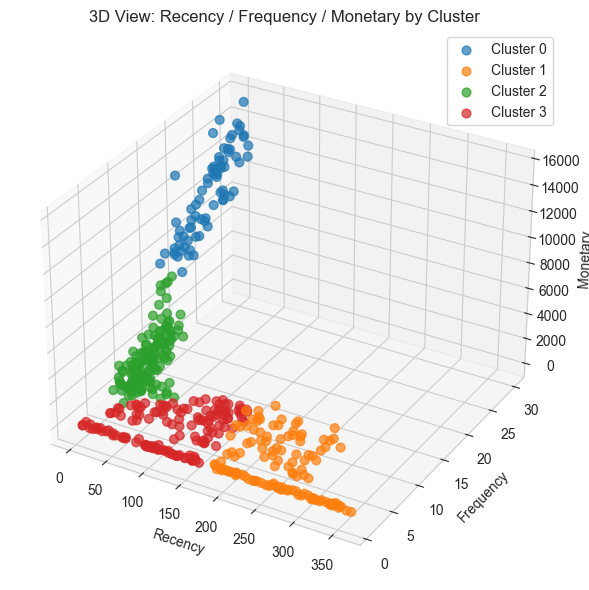

In [14]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

for c in sorted(rfm["Cluster"].unique()):
    subset = rfm[rfm["Cluster"] == c]
    ax.scatter(subset["Recency"], subset["Frequency"], subset["Monetary"],
               label=f"Cluster {c}", s=40, alpha=0.7)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D View: Recency / Frequency / Monetary by Cluster")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Cluster Profiling

Mean feature values per cluster, plus cluster size, to characterise each customer type.

In [15]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum"),
).round(1).sort_values("Avg_Monetary", ascending=False)

cluster_profile["% of Customers"] = (cluster_profile["Customers"] / cluster_profile["Customers"].sum() * 100).round(1)
cluster_profile["% of Revenue"] = (cluster_profile["Total_Revenue"] / cluster_profile["Total_Revenue"].sum() * 100).round(1)
cluster_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,% of Customers,% of Revenue
Cluster,,,,,,,
0,74,11.1,23.0,10622.1,786034.9,14.8,61.4
2,150,25.2,9.9,2373.6,356032.6,30.0,27.8
1,124,251.6,3.3,636.2,78886.1,24.8,6.2
3,152,101.4,4.2,386.5,58751.7,30.4,4.6


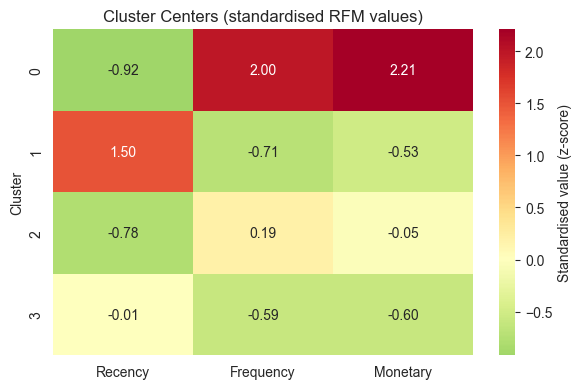

In [16]:
# Heatmap of standardised cluster centers - easy to read "high/low" at a glance
centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centers.index.name = "Cluster"

plt.figure(figsize=(6, 4))
sns.heatmap(centers, annot=True, cmap="RdYlGn_r", center=0, fmt=".2f",
            cbar_kws={"label": "Standardised value (z-score)"})
plt.title("Cluster Centers (standardised RFM values)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


**Reading the heatmap:** for Recency, *lower/green is better* (more recent); for
Frequency and Monetary, *higher/red is better*. This lets you eyeball each cluster's
personality at a glance without staring at raw numbers.

Based on the profile table and heatmap, here is how each cluster typically reads:

| Cluster pattern | Likely label | Description |
|---|---|---|
| Low recency, high frequency, high monetary | **Champions** | Buy often, spent recently, highest value — your best customers |
| Moderate recency, moderate frequency/monetary | **Loyal / Steady** | Regular repeat buyers, solid but not top-tier spend |
| High recency, low-moderate frequency | **At Risk / Lapsing** | Used to buy, haven't been back in a while — churn risk |
| High recency, very low frequency, low monetary | **New / One-time / Low-value** | Single or rare purchase, low spend — needs nurturing |

(Exact labels depend on which cluster index maps to which pattern — check the profile
table above; cluster identities can shift between runs.)

## 9. Customers per Cluster — Bar Chart

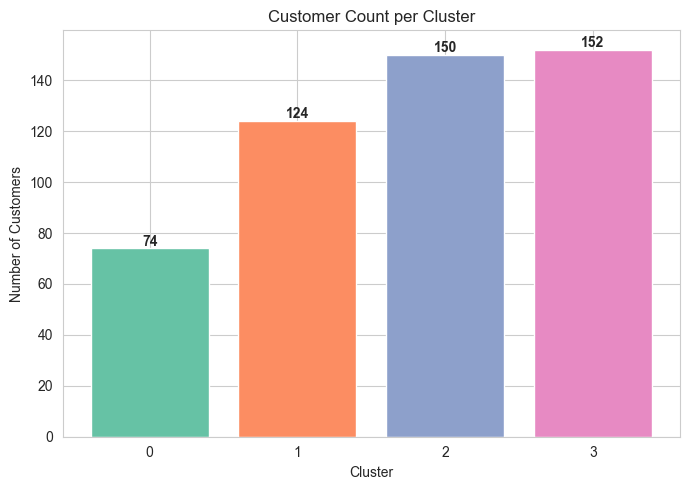

In [17]:
plt.figure(figsize=(7, 5))
counts = rfm["Cluster"].value_counts().sort_index()
bars = plt.bar(counts.index.astype(str), counts.values, color=sns.color_palette("Set2", OPTIMAL_K))
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Count per Cluster")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1, str(val), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Insights & Recommended Marketing Actions

Interpreting the profile table above (adapt the specific cluster numbers to whatever your
own run produces — sort by `Avg_Monetary` / `Avg_Recency` to re-identify each group):

**🏆 Champions (low Recency, high Frequency, high Monetary)**
- Highest-value, most engaged customers — small in number but disproportionate revenue share.
- *Action:* VIP loyalty perks, early access to new products, personal outreach, referral incentives. Protect this segment — losing them is costly.

**💚 Loyal / Steady (moderate on all three)**
- Reliable repeat buyers who haven't yet reached top-tier spend.
- *Action:* Cross-sell and upsell campaigns, loyalty-points nudges, bundle offers to increase basket size and order frequency.

**⚠️ At Risk / Lapsing (high Recency, was previously active)**
- Used to purchase but have gone quiet — classic churn signal.
- *Action:* Win-back email/SMS campaigns with time-limited discounts, "we miss you" messaging, satisfaction surveys to diagnose why they left.

**🌱 New / One-time / Low-value (high Recency, low Frequency, low Monetary)**
- Either brand-new customers or one-off bargain shoppers.
- *Action:* Onboarding email sequences, first-repeat-purchase discount, product recommendations based on their single purchase to encourage a second order.

**General takeaways:**
- Check the `% of Revenue` vs `% of Customers` columns in the profile table — segments with revenue share well above their customer share are your highest-priority retention targets.
- Recency is usually the most actionable lever: it's cheaper to reactivate a lapsing customer than to acquire a new one.
- Re-run this pipeline periodically (e.g. monthly) — customers migrate between segments over time, and campaign effectiveness can be measured by tracking that migration.

---
*Next steps: attach real acquisition-channel and product-category data to see which channels/products produce the most Champions, and A/B test the recommended campaigns per segment.*